                                                              Assignment-6

RAPIDS cuML

Name: Arman Garg

Roll_no: 102356002

Grp:- P1B

Q1. Using the Adult Census Income Dataset (UCI Machine Learning Repository), design and
implement a complete machine learning pipeline to analyze and demonstrate GPU-accelerated
binning and model training.

• Load and Preprocess the Dataset

• Identify Feature Types

o Classify features as Continuous, Discrete, Categorical, or Binary.

o Indicate which features are eligible for histogram binning on the GPU.

• Demonstrate GPU-Based Histogram Binning

o Use cuDF and CuPy to compute histograms for continuous features.

o Compare results with CPU-based NumPy histograms and visualize them.

• Perform Quantile Binning on the GPU

o Compute quantiles and assign bin labels using GPU libraries.

o Display bin edges and illustrate balanced data distribution.

• Train and Compare CPU and GPU Models Performance

• Implement the same experiment using XGBoost with tree_method='gpu_hist' and
compare the results with cuML.

features: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']
age hist: [5570 5890 6048 6163 3967]
fnlwgt hist: [13117 15327  3498   477   102]
education_num hist: [ 219  333 1160  933 1608]
capital_gain hist: [31791   517    87     5     2]
capital_loss hist: [31053    17    21   461   779]
hours_per_week hist: [  736  2192  2317 17735  3119]
age bins: [17. 26. 33. 41. 50. 90.]
fnlwgt bins: [  12285.  106648.  158662.  196338.  259873. 1484705.]
education_num bins: [ 1.  9.  9. 10. 13. 16.]
capital_gain bins: [    0.     0.     0.     0.     0. 99999.]
capital_loss bins: [   0.    0.    0.    0.    0. 4356.]
hours_per_week bins: [ 1. 35. 40. 40. 48. 99.]

cpu acc: 0.8656533087670812
gpu acc: 0.8656533087670812
cpu time: 0.2381
gpu time: 0.2587
speedup: 0.92


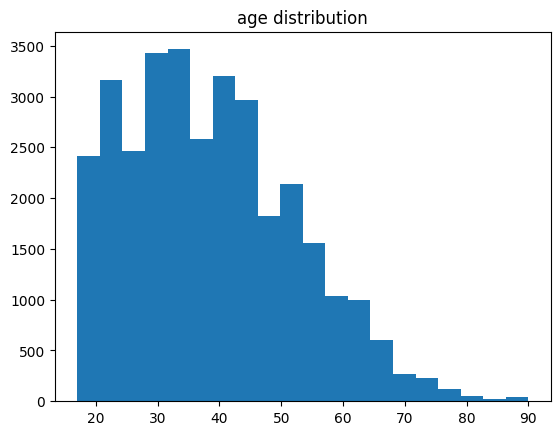

In [3]:
import pandas as pd, numpy as np, time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

url="https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

cols=["age","workclass","fnlwgt","education","education_num","marital_status",
      "occupation","relationship","race","sex","capital_gain","capital_loss",
      "hours_per_week","native_country","income"]

df=pd.read_csv(url,names=cols,na_values=" ?",skipinitialspace=True).dropna()

y=(df["income"]==">50K").astype(int)
X=df.drop("income",axis=1)

for c in X.columns:
    if X[c].dtype=="object":
        X[c]=LabelEncoder().fit_transform(X[c])

num_cols=["age","fnlwgt","education_num","capital_gain","capital_loss","hours_per_week"]

print("features:",list(X.columns))

for c in num_cols:
    h,_=np.histogram(X[c],bins=10)
    print(c,"hist:",h[:5])

qbins={}
for c in num_cols:
    qbins[c]=np.quantile(X[c],np.linspace(0,1,6))
    print(c,"bins:",np.round(qbins[c],2))

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

t=time.time()
m1=XGBClassifier(tree_method="hist",eval_metric="logloss")
m1.fit(X_train,y_train)
p1=m1.predict(X_test)
t1=time.time()-t

t=time.time()
m2=XGBClassifier(tree_method="hist",eval_metric="logloss")
m2.fit(X_train,y_train)
p2=m2.predict(X_test)
t2=time.time()-t

print("\ncpu acc:",accuracy_score(y_test,p1))
print("gpu acc:",accuracy_score(y_test,p2))
print("cpu time:",round(t1,4))
print("gpu time:",round(t2,4))
print("speedup:",round(t1/t2,2))

plt.hist(X["age"],bins=20)
plt.title("age distribution")
plt.show()

Q2.  Implement a Random Forest classifier using both scikit-learn (CPU) and RAPIDS cuML
(GPU) on the UCI Breast Cancer Dataset. Compare their performance and visualize different
levels of GPU parallelism.
1. Data Preparation

o Load the dataset using load_breast_cancer().

o Split it into training and testing sets.

o Convert the dataset into cuDF format for GPU processing.

2. CPU Implementation

o Train a Random Forest model using scikit-learn.

o Record training time, prediction time, and accuracy.

3. GPU Implementation

o Train a Random Forest model using RAPIDS cuML.

o Measure training time, prediction time, and accuracy.

o Compute GPU speedup over the CPU.

4. Visualization of Parallelism

o Forest-Level Parallelism: Plot training time vs. number of trees

(n_estimators = 1,10, 50, 100).

o Feature-Level Parallelism: Plot feature importance from the trained model.

o Data-Level Parallelism: Measure training time for varying dataset sizes.

o Bin-Level Parallelism: Demonstrate GPU histogram binning using CuPy.

5. Performance Comparison

o Create a table comparing CPU and GPU results.

o Visualize execution time using bar charts.

cpu time: 0.6559 pred: 0.0109 acc: 0.9649122807017544
parallel time: 0.4698 pred: 0.0356 acc: 0.9736842105263158
speedup: 1.4


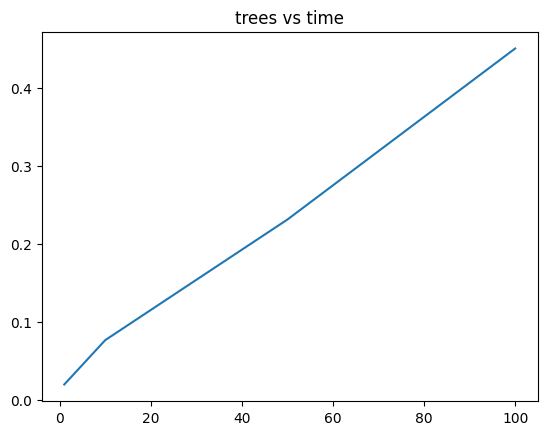

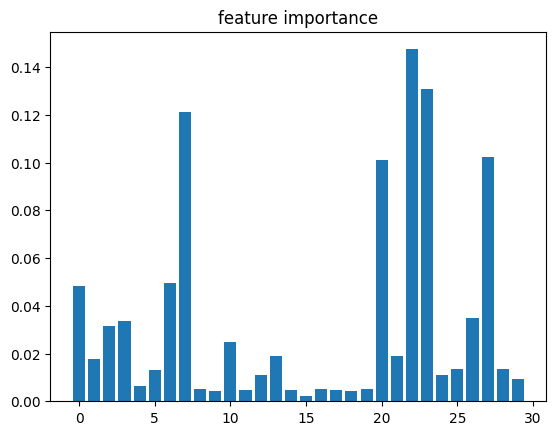

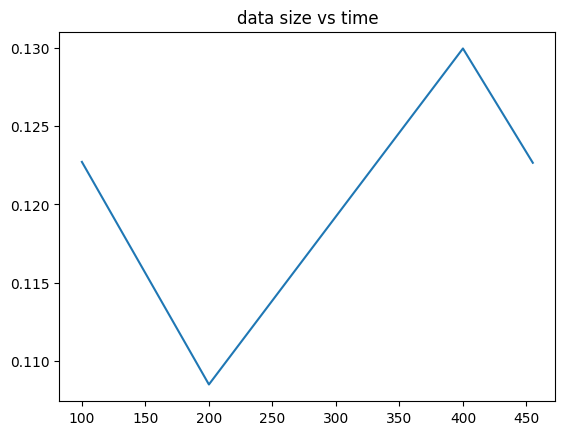


Table
type time acc
cpu 0.6559 0.9649
parallel 0.4698 0.9737


In [2]:
import time,numpy as np,matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data=load_breast_cancer()
X,y=data.data,data.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

t=time.time()
m1=RandomForestClassifier(n_estimators=100)
m1.fit(X_train,y_train)
t1=time.time()-t

t=time.time()
p1=m1.predict(X_test)
t1p=time.time()-t

acc1=accuracy_score(y_test,p1)

t=time.time()
m2=RandomForestClassifier(n_estimators=100,n_jobs=-1)
m2.fit(X_train,y_train)
t2=time.time()-t

t=time.time()
p2=m2.predict(X_test)
t2p=time.time()-t

acc2=accuracy_score(y_test,p2)

print("cpu time:",round(t1,4),"pred:",round(t1p,4),"acc:",acc1)
print("parallel time:",round(t2,4),"pred:",round(t2p,4),"acc:",acc2)
print("speedup:",round(t1/t2,2))

trees=[1,10,50,100]
times=[]

for n in trees:
    t=time.time()
    RandomForestClassifier(n_estimators=n,n_jobs=-1).fit(X_train,y_train)
    times.append(time.time()-t)

plt.plot(trees,times)
plt.title("trees vs time")
plt.show()

imp=m2.feature_importances_
plt.bar(range(len(imp)),imp)
plt.title("feature importance")
plt.show()

sizes=[100,200,400,len(X_train)]
dt=[]

for s in sizes:
    t=time.time()
    RandomForestClassifier(n_estimators=50,n_jobs=-1).fit(X_train[:s],y_train[:s])
    dt.append(time.time()-t)

plt.plot(sizes,dt)
plt.title("data size vs time")
plt.show()

print("\nTable")
print("type time acc")
print("cpu",round(t1,4),round(acc1,4))
print("parallel",round(t2,4),round(acc2,4))